<a href="https://colab.research.google.com/github/yoghan007/dlv_exp/blob/main/Implementation_of_Basic_Image_Processing_Operations_Including_Feature_Representation_and_Feature_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Image:


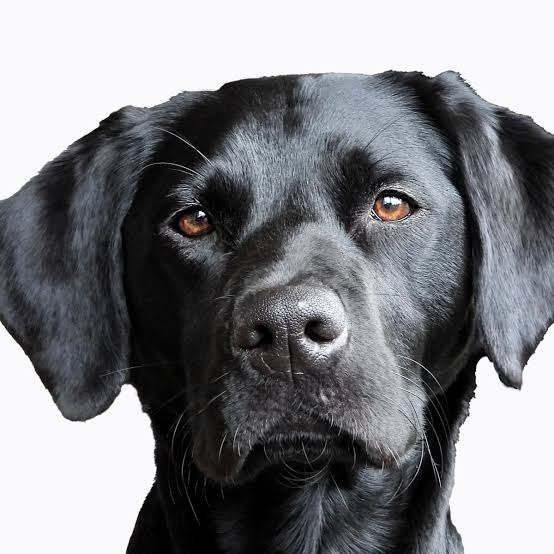

Grayscale Image:


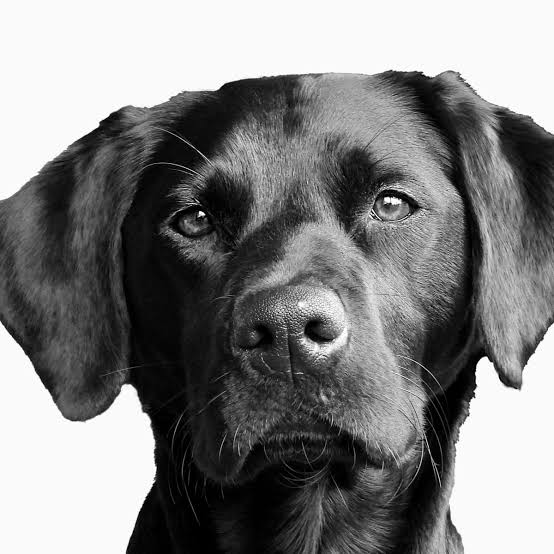

Blurred Image:


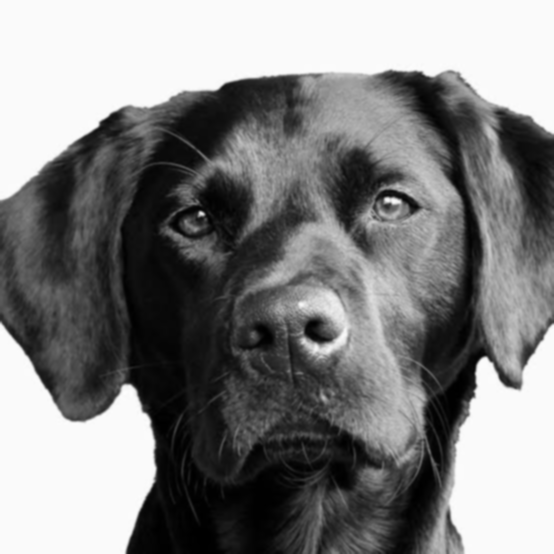

Canny Edge Image:


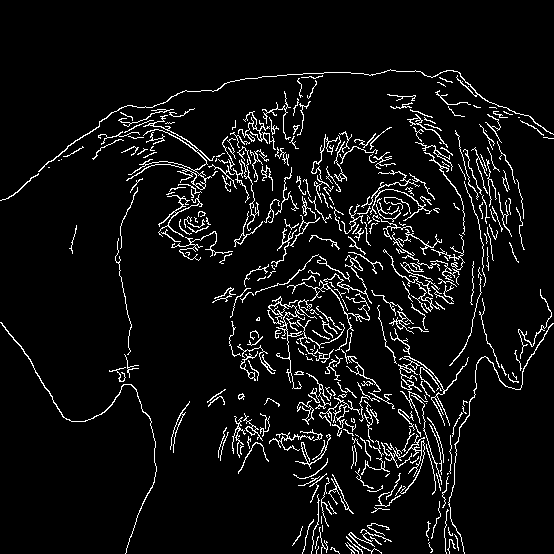

Corners Detected:


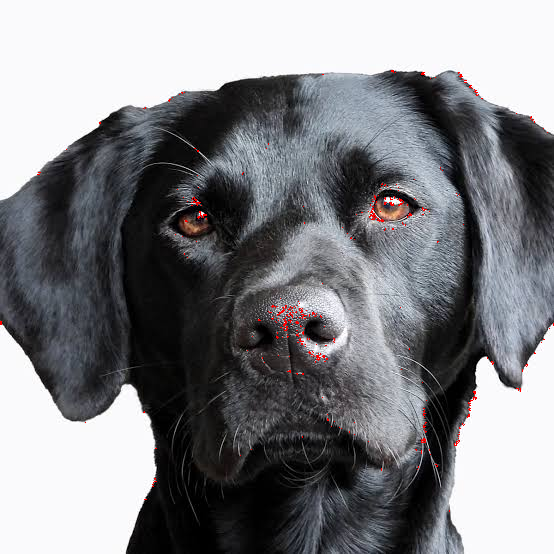

Blobs Detected:


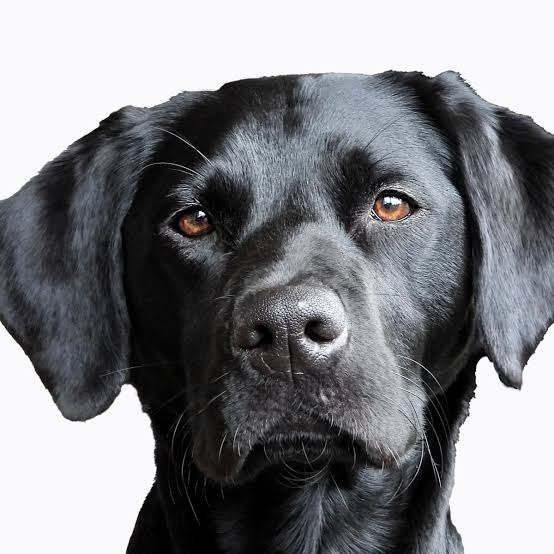

In [21]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow # Import cv2_imshow

# Correct the path to the image
img = cv2.imread('/content/sample.jpg') # Corrected path here

# Check if the image was loaded successfully
if img is None:
    print("Error: Could not load image 'sample.jpg'. Please ensure the file exists at '/content/sample.jpg'.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)

    corners = cv2.cornerHarris(np.float32(gray), 2, 3, 0.04)
    img_corners = img.copy()
    img_corners[corners > 0.01 * corners.max()] = [0, 0, 255]
    detector = cv2.SimpleBlobDetector_create()
    keypoints = detector.detect(gray)
    img_blobs = cv2.drawKeypoints(img, keypoints, None, (0, 255, 0),
cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    # Use cv2_imshow for displaying images in Colab
    print("Original Image:")
    cv2_imshow(img)
    print("Grayscale Image:")
    cv2_imshow(gray)
    print("Blurred Image:")
    cv2_imshow(blur)
    print("Canny Edge Image:")
    cv2_imshow(edges)
    print("Corners Detected:")
    cv2_imshow(img_corners)
    print("Blobs Detected:")
    cv2_imshow(img_blobs)
    # cv2.waitKey(0) and cv2.destroyAllWindows() are not needed with cv2_imshow